In [2]:
import numpy as np
from sklearn.linear_model import LinearRegression
import xarray as xr
import sage_data_client
import pandas as pd
import cmweather
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import matplotlib.pyplot as plt

# Glob

In [ ]:
import glob
import xarray as xr

# 1) Collect all March, April, May files (full months):
file_paths = []
for mo in ["03", "04", "05", "06", "07", "08", "09", "10", "11"]:
    pattern = (
        "/nfs/gce/projects/crocus/data/ingested-data/long-term-sites/"
        "neiu/atmos-wxt-a1/crocus-NEIU-wxt-a1_2024" + mo + "*.nc"
    )
    file_paths.extend(sorted(glob.glob(pattern)))

# 2) Collect only June 1 files (i.e. “20250601*.nc”) so that June 1 is included, but nothing after:
# june1_pattern = (
#     "/nfs/gce/projects/crocus/data/ingested-data/long-term-sites/"
#     "neiu/neiu-wxt-a1/crocus-NEIU-wxt-a1_20241101*.nc"
# )
# file_paths.extend(sorted(glob.glob(june1_pattern)))

# # 3) Open all together, combining by coordinates (time):
ds_wxt = xr.open_mfdataset(file_paths, combine="by_coords")

print(ds_wxt)

<xarray.Dataset> Size: 142MB
Dimensions:        (time: 1781045)
Coordinates:
  * time           (time) datetime64[ns] 14MB 2024-03-01 ... 2024-11-30T23:59:50
Data variables:
    temperature    (time) float64 14MB dask.array<chunksize=(8640,), meta=np.ndarray>
    humidity       (time) float64 14MB dask.array<chunksize=(8640,), meta=np.ndarray>
    pressure       (time) float64 14MB dask.array<chunksize=(8640,), meta=np.ndarray>
    rainfall       (time) float64 14MB dask.array<chunksize=(8640,), meta=np.ndarray>
    dewpoint       (time) float64 14MB dask.array<chunksize=(8640,), meta=np.ndarray>
    wetbulb        (time) float64 14MB dask.array<chunksize=(8640,), meta=np.ndarray>
    wind_dir_10s   (time) float64 14MB dask.array<chunksize=(8640,), meta=np.ndarray>
    wind_mean_10s  (time) float64 14MB dask.array<chunksize=(8640,), meta=np.ndarray>
    wind_max_10s   (time) float64 14MB dask.array<chunksize=(8640,), meta=np.ndarray>
Attributes:
    conventions:  CF 1.10
    site_ID:  

# This function converts the WXT data (in netCDF form) to hourly intervals

In [ ]:
import xarray as xr


def resample_rainfall_where_temp_above_5(ds):
    """
    Given an xarray.Dataset (or DataArray) with:
      - coords:   "time" (dtype datetime64[ns])
      - data_vars:
         * "rainfall"    : running (cumulative) rainfall [mm]
         * "temperature" : temperature [°C]

    This returns an xarray.DataArray called "hourly_rainfall" that is
    indexed by hourly timestamps.  For each hour, it computes:
        last(rainfall[T≥5])  -  first(rainfall[T≥5])
    i.e. only sub-hourly samples where temperature ≥ 5°C are used to define
    the “first” and “last” in that hour.  If there are zero valid samples
    (all T<5 in that hour), that hour's accumulation is set to 0.0.

    Returns
    -------
    hourly_rain : xarray.DataArray
        Dimensions: (time=Number_of_hours)
        Values:   hourly accumulation in mm (float64)
        Where time is the left‐edge of each 1-hour bin (e.g. 2025-06-05T00:00, 01:00, …).
    """
    # 1) Mask rainfall to only keep times where T >= 5.0
    # ---------------------------------------------------
    # If T < 5, set rainfall to NaN so that .first() / .last() ignore those points.
    rain_masked = ds["rainfall"].where(ds["temperature"] >= 5.0)

    # 2) Resample masked rainfall to 1-hour bins
    #    Compute first‐and‐last in each hour
    # ---------------------------------------------------
    # .resample(time="1H").first() gives the first non‐NaN rainfall in that hour,
    # (or NaN if none).  Similarly for .last().
    first_in_hour = rain_masked.resample(time="1H").first()
    last_in_hour = rain_masked.resample(time="1H").last()

    # 3) Compute accumulation = last - first
    # ---------------------------------------------------
    hourly_accum = last_in_hour - first_in_hour

    # 4) Where no valid points in that hour, both first & last are NaN → result NaN.
    #    Replace those NaNs with 0.0 (since “no rainfall counted when T<5 throughout”)
    hourly_accum = hourly_accum.fillna(0.0)

    # 5) Rename the DataArray & attach a simple attribute
    hourly_accum.name = "hourly_rainfall_>=5C"
    hourly_accum.attrs["long_name"] = "Hourly rainfall where T >= 5 C"
    hourly_accum.attrs["units"] = "mm"

    return hourly_accum


hourly_rain = resample_rainfall_where_temp_above_5(ds_wxt)

# (D) Look at the output:
print(hourly_rain)
# xarray.DataArray 'hourly_rainfall_>=5C' (time: N_hours)
#   array([..., ..., ...], dtype=float64)
# Coordinates:
#   * time     (time) datetime64[ns] 2025-06-05T00:00:00 ... 2025-06-06T23:00:00

# (E) If you want a Pandas DataFrame:
df_wxt_hourly = hourly_rain.to_dataframe().reset_index()
df_wxt_hourly.to_csv("hourly_rainfall_wxt_2024.csv", index=False)

/home/bweart/miniconda/envs/crocus/lib/python3.11/site-packages/xarray/groupers.py:498: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(
/home/bweart/miniconda/envs/crocus/lib/python3.11/site-packages/xarray/groupers.py:498: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


<xarray.DataArray 'hourly_rainfall_>=5C' (time: 6600)> Size: 53kB
dask.array<where, shape=(6600,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 53kB 2024-03-01 ... 2024-11-30T23:00:00
Attributes:
    long_name:  Hourly rainfall where T >= 5 C
    units:      mm


# These cells are used for converting the NEXRAD data into hourly intervals, as well as crafting the Z and Rainfall rate variables

In [ ]:
import xarray as xr
from pathlib import Path

# List all your files
files = [
    "nexrad_nc/nxrd_data_03_05_03.nc",
    "nexrad_nc/nxrd_data_linreg_2024_pt2.nc",
    "nexrad_nc/nxrd_data_linreg_2024_pt3.nc",
    "kdp_ref_data.nc",
]

# Mapping of all possible old→new names
COMMON_RENAMES = {
    "reflectivity_lowest_gate": "reflectivity",
    "height_lowest_gate": "height",
    "height_at_lowest_gate": "height",
    "kdp_lowest_gate": "kdp",
}

datasets = []
for fn in files:
    ds = xr.open_dataset(fn)
    # Pick only the keys that actually exist in this ds (vars or coords)
    to_rename = {
        old: new
        for old, new in COMMON_RENAMES.items()
        if old in ds.data_vars or old in ds.coords
    }
    ds = ds.rename(to_rename)

    # If height ended up as a coord, turn it back into a var
    if "height" in ds.coords:
        ds = ds.reset_coords("height", drop=True)

    # Drop kdp if it’s still there
    if "kdp" in ds.data_vars:
        ds = ds.drop_vars("kdp")

    datasets.append(ds)

# Concatenate along time, outer join on vars/coords
combined = xr.concat(
    datasets, dim="time", join="outer", data_vars="minimal", coords="minimal"
)

# Drop duplicate time stamps
times = combined.indexes["time"]
combined = combined.sel(time=~times.duplicated(keep="first"))

# Sort by time
combined = combined.sortby("time")

print(combined)
combined.to_netcdf("combined_nexrad.nc")

<xarray.Dataset> Size: 3MB
Dimensions:                         (time: 83765)
Coordinates:
  * time                            (time) datetime64[ns] 670kB 2024-03-01T00...
Data variables:
    reflectivity                    (time) float64 670kB -4.0 nan ... nan nan
    height                          (time) float64 670kB 1.176e+03 ... nan
    differential_phase_lowest_gate  (time) float64 670kB nan nan nan ... nan nan
Attributes:
    history:  Created 2025-06-11T12:47:39.328295


In [ ]:
import xarray as xr

nxrd = xr.open_dataset("combined_nexrad.nc")
nxrd = nxrd.rename({"reflectivity": "reflectivity"})

In [ ]:
def var_creation(ds):
    ds["reflectivity"] = ds["reflectivity"].fillna(0)
    ds["reflectivity"] = ds["reflectivity"].where(ds["reflectivity"] < 55)
    ds["Z"] = 10 ** (ds["reflectivity"] / 10)
    ds["rainfall_rate"] = (ds["Z"] / 300) ** (1 / 1.4)
    ds["rainfall_rate_new_zr"] = 0.03 * ds["Z"] ** 0.60

    ds = ds.drop_vars("differential_phase_lowest_gate")
    return ds


nxrd = var_creation(nxrd)

In [20]:
nxrd

<xarray.Dataset> Size: 4MB
Dimensions:               (time: 83765)
Coordinates:
  * time                  (time) datetime64[ns] 670kB 2024-03-01T00:03:29.051...
Data variables:
    reflectivity          (time) float64 670kB -4.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    height                (time) float64 670kB ...
    Z                     (time) float64 670kB 0.3981 1.0 1.0 ... 1.0 1.0 1.0
    rainfall_rate         (time) float64 670kB 0.008809 0.01701 ... 0.01701
    rainfall_rate_new_zr  (time) float64 670kB 0.4627 1.06 1.06 ... 1.06 1.06
Attributes:
    history:  Created 2025-06-11T12:47:39.328295

# This function computes the hourly averages for whichever variable is selected. In this case, its reflectivity

In [ ]:
import pandas as pd

# ——— your existing helper ——————————————————————————————————————


def compute_hourly_average(ds, varname):
    """
    Compute hourly average of a variable (no height dimension).
    If varname=="rainfall_rate", also compute hourly accumulation.

    Returns a DataFrame with:
      - time
      - hourly_avg_<varname>
      - (if rainfall_rate) hourly_accum_<varname>
    """
    # 1) sort & ensure datetime64
    ds = ds.sortby("time")
    ds = ds.assign_coords(time=pd.to_datetime(ds["time"].values))

    # 2) extract var & compute hourly mean
    var = ds[varname]
    hourly_avg = var.resample(time="1H").mean()
    hourly_series = hourly_avg.to_series().rename(f"hourly_avg_{varname}")
    hourly_df = hourly_series.to_frame().reset_index()

    # 3) if rainfall_rate, also compute accumulation
    if (
        varname == "rainfall_rate"
        or varname == "rainfall_rate_new_zr"
        or varname == "rainfall_rate_new_zr_wxt"
    ):
        times = var["time"].values
        dt = np.diff(times)
        dt_hrs = np.concatenate([[0.0], (dt / np.timedelta64(1, "h")).astype(float)])
        dt_da = xr.DataArray(dt_hrs, coords=[times], dims=["time"])
        depth = var * dt_da
        hourly_accum = depth.resample(time="1H").sum()
        hourly_df[f"hourly_accum_{varname}"] = hourly_accum.to_series().values

    return hourly_df


# ——— now apply Fix 1 when concatenating ————————————————————————

# 1) build a list of hourly-DataFrames, each with time set as index
dfs = []
for var in nxrd.data_vars:
    df = compute_hourly_average(nxrd, var)
    df = df.set_index("time")  # <— move time into the index
    dfs.append(df)

# 2) concatenate side-by-side on that single index
hourly_all = pd.concat(dfs, axis=1)

# 3) bring time back as a column
hourly_all = hourly_all.reset_index()

# 4) write out a clean CSV
# hourly_all.to_csv("/mnt/data/nexrad_hourly_vars_with_wxt.csv", index=False)

/home/bweart/miniconda/envs/crocus/lib/python3.11/site-packages/xarray/groupers.py:498: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(
/home/bweart/miniconda/envs/crocus/lib/python3.11/site-packages/xarray/groupers.py:498: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(
/home/bweart/miniconda/envs/crocus/lib/python3.11/site-packages/xarray/groupers.py:498: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(
/home/bweart/miniconda/envs/crocus/lib/python3.11/site-packages/xarray/groupers.py:498: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(
/home/bweart/miniconda/envs/crocus/lib/python3.11/site-packages/xarray/groupers.py:498: FutureWarning: 'H' is deprec

In [11]:
hourly_all

,time,hourly_avg_reflectivity,hourly_avg_height,hourly_avg_Z,hourly_avg_rainfall_rate,hourly_accum_rainfall_rate,hourly_avg_rainfall_rate_new_zr,hourly_accum_rainfall_rate_new_zr
0,2024-03-01 00:00:00,-0.444444,1137.055556,0.933123,0.016096,0.015734,0.993634,0.980673
1,2024-03-01 01:00:00,-0.562500,1176.500000,0.919352,0.015895,0.014559,0.979645,0.896966
2,2024-03-01 02:00:00,-0.722222,1141.500000,0.884494,0.015459,0.015971,0.946012,0.977317
3,2024-03-01 03:00:00,0.000000,1176.500000,1.000000,0.017007,0.017897,1.060000,1.115480
4,2024-03-01 04:00:00,0.000000,1176.500000,1.000000,0.017007,0.015891,1.060000,0.990413
...,...,...,...,...,...,...,...,...
11084,2025-06-05 20:00:00,-1.528846,NaN,0.804859,0.014178,0.014345,0.861711,0.872009
11085,2025-06-05 21:00:00,-0.701392,NaN,1.787436,0.021541,0.020422,1.650764,1.547370
11086,2025-06-05 22:00:00,-1.951923,NaN,0.770686,0.013570,0.013598,0.823858,0.823930
11087,2025-06-05 23:00:00,-2.365385,NaN,0.674219,0.012491,0.012375,0.734915,0.727959


In [25]:
hourly_all.to_csv("csv_files/nexrad_hourly_vars_wxt_new.csv", index=False)

# This cell below is used to generate hourly averaged rainfall accumulation

### NOT NEEDED


In [ ]:
import xarray as xr
import pandas as pd
import numpy as np


def compute_hourly_accumulation(ds, rate_var="rainfall_rate"):
    """
    Given an xarray.Dataset with a 1D rate variable in mm/hr,
    compute the hourly accumulated depth in mm.

    Parameters
    ----------
    ds : xarray.Dataset
        Must contain a time coordinate (datetime64[ns]) and a data variable
        `rate_var` with dims ("time",).
    rate_var : str
        Name of the instantaneous rate variable (mm/hr).

    Returns
    -------
    hourly_accum : xarray.DataArray
        Hourly accumulation in mm, dims=("time",), coordinate time at each hour.
    """
    # 1) Ensure time is datetime64
    ds = ds.assign_coords(time=pd.to_datetime(ds["time"].values))

    # 2) Extract the rate DataArray
    rate = ds[rate_var]  # dims = ("time",), mm/hr

    # 3) Compute dt in hours via numpy.diff
    times = rate["time"].values  # datetime64 array, length N
    dt_np = np.diff(times)  # length N-1, timedelta64[ns]
    dt_hours = np.concatenate(
        [[0.0], (dt_np / np.timedelta64(1, "h")).astype(float)]
    )  # length N

    # 4) Wrap dt_hours in a DataArray aligned to time
    dt_da = xr.DataArray(
        dt_hours, dims=["time"], coords={"time": times}, name="delta_hours"
    )

    # 5) Compute depth increment [mm] = rate [mm/hr] * dt [hr]
    depth = rate * dt_da

    # 6) Resample to hourly bins and sum to get accumulated depth per hour
    hourly_accum = depth.resample(time="1H").sum()
    hourly_accum.name = f"hourly_accum_{rate_var}"
    hourly_accum.attrs["units"] = "mm"
    hourly_accum.attrs["long_name"] = f"Hourly accumulation from {rate_var}"

    return hourly_accum


hourly_accum = compute_hourly_accumulation(nxrd, rate_var="rainfall_rate")

/home/bweart/miniconda/envs/crocus/lib/python3.11/site-packages/xarray/groupers.py:498: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


In [ ]:
wxt_hourly_2024 = pd.read_csv("hourly_rainfall_wxt_2024.csv")
wxt_hourly_2025 = pd.read_csv("csv_files/wxt_mar_thru_jun_rain_accumulation_neiu.csv")
wxt_hourly_2024_2025 = pd.concat([wxt_hourly_2024, wxt_hourly_2025], ignore_index=True)
wxt_hourly_2024_2025.to_csv("csv_files/wxt_hourly_2024_2025.csv")

In [ ]:
hourly_all.to_csv("test.csv")

# This cell below merges the dataframes

In [1]:
import pandas as pd
import numpy as np


def load_and_prepare_xy(
    truth_csv: str,
    non_truth_csv: str,
    truth_col: str = "hourly_rainfall_>=5C",
    non_truth_col: str = "hourly_avg_rainfall_rate_new_zr",
    rename_truth: str = "rain_rate",
    rename_non_truth: str = "hourly_avg_rainfall_rate_new_zr",
) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """
    Load two CSVs (truth and non‐truth), merge on time, clean, and return X, y, and the merged DataFrame.

    Parameters
    ----------
    truth_csv : str
        Path to the “ground truth” CSV, must contain columns ["time", truth_col].
    non_truth_csv : str
        Path to the “forecast/non‐truth” CSV, must contain columns ["time", non_truth_col].
    truth_col : str
        Name of the accumulation column in the truth CSV.
    non_truth_col : str
        Name of the accumulation column in the non‐truth CSV.
    rename_truth : str
        New column name for the truth variable after loading.
    rename_non_truth : str
        New column name for the non‐truth variable after loading.

    Returns
    -------
    X : np.ndarray of shape (n_samples, 1)
        The predictor (non‐truth) values.
    y : np.ndarray of shape (n_samples,)
        The target (truth) values.
    df : pd.DataFrame
        The merged and cleaned DataFrame with columns
        ["time", rename_truth, rename_non_truth].
    """
    # 1) Read CSVs
    df_truth = pd.read_csv(truth_csv, parse_dates=["time"])
    df_non_truth = pd.read_csv(non_truth_csv, parse_dates=["time"])

    # 2) Rename accumulation columns
    df_truth = df_truth.rename(columns={truth_col: rename_truth})
    df_non_truth = df_non_truth.rename(columns={non_truth_col: rename_non_truth})

    # 3) Strip timezone if present
    for df_ in (df_truth, df_non_truth):
        if df_["time"].dt.tz is not None:
            df_["time"] = df_["time"].dt.tz_convert(None)

    # 4) Merge on time
    df = pd.merge(df_truth, df_non_truth, on="time", how="inner")

    # 5) Drop any rows with missing values in either series
    df = df.dropna(subset=[rename_truth, rename_non_truth])

    # 6) Prepare X, y
    X = df[[rename_non_truth]].to_numpy()  # shape = (n, 1)
    y = df[rename_truth].to_numpy()  # shape = (n,)

    return X, y, df


truth_csv = "csv_files/wxt_hourly_2024_2025.csv"
non_truth_csv = "csv_files/nexrad_hourly_vars_wxt_new.csv"

X, y, df = load_and_prepare_xy(truth_csv, non_truth_csv)

# print(f"Loaded {len(df_merged)} samples.")
# print(df_merged.head())

In [15]:
df

,Unnamed: 0_x,time,rain_rate,Unnamed: 0_y,hourly_avg_reflectivity,hourly_avg_height,hourly_avg_Z,hourly_avg_rainfall_rate,hourly_accum_rainfall_rate,hourly_avg_rainfall_rate_new_zr,hourly_accum_rainfall_rate_new_zr
0,0,2024-03-01 00:00:00,0.0,0,-0.444444,1137.055556,0.933123,0.016096,0.015734,0.993634,0.980673
1,1,2024-03-01 01:00:00,0.0,1,-0.562500,1176.500000,0.919352,0.015895,0.014559,0.979645,0.896966
2,2,2024-03-01 02:00:00,0.0,2,-0.722222,1141.500000,0.884494,0.015459,0.015971,0.946012,0.977317
3,3,2024-03-01 03:00:00,0.0,3,0.000000,1176.500000,1.000000,0.017007,0.017897,1.060000,1.115480
4,4,2024-03-01 04:00:00,0.0,4,0.000000,1176.500000,1.000000,0.017007,0.015891,1.060000,0.990413
...,...,...,...,...,...,...,...,...,...,...,...
8539,8539,2025-06-01 19:00:00,0.0,10987,1.687500,NaN,2.619085,0.029645,0.027935,2.378200,2.244033
8540,8540,2025-06-01 20:00:00,0.0,10988,0.694444,NaN,1.652728,0.022811,0.024298,1.620106,1.726260
8541,8541,2025-06-01 21:00:00,0.0,10989,1.000000,NaN,1.802196,0.024063,0.022592,1.744055,1.635899
8542,8542,2025-06-01 22:00:00,0.0,10990,4.615744,NaN,3.729661,0.041638,0.045394,3.400224,3.711501


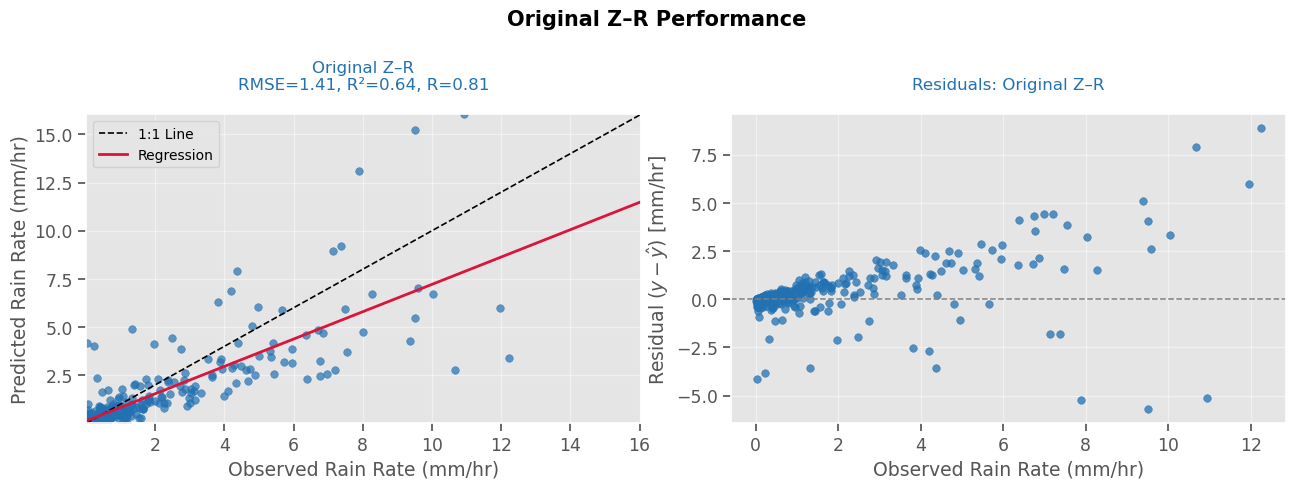

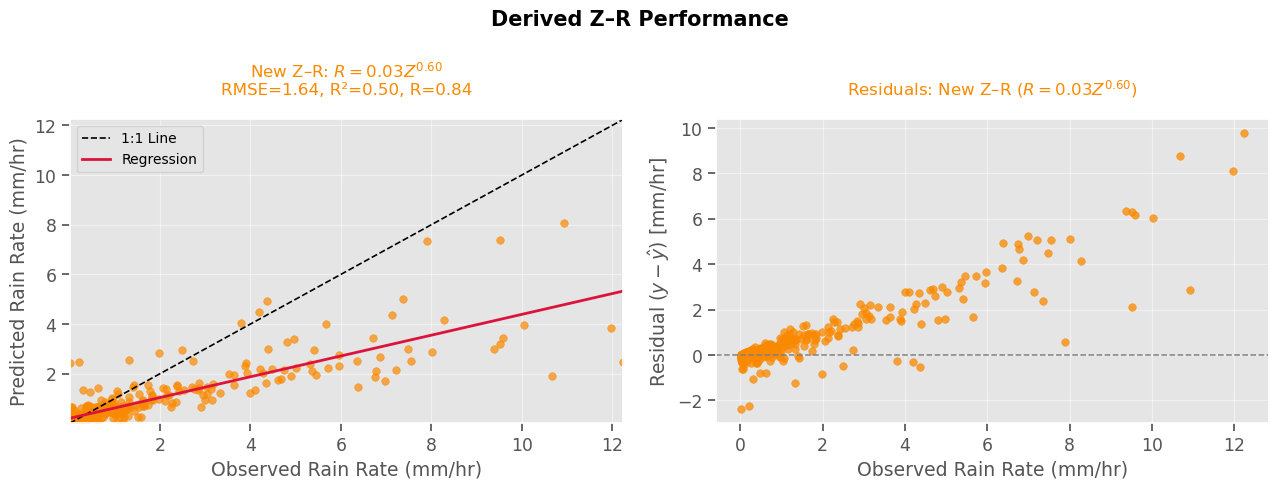

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import linregress

# --- Data setup (replace with your DataFrame loading) ---
truth = df_masked["rain_rate"]
pred_orig_zr = df_masked["hourly_avg_rainfall_rate"]
pred_new_zr = df_masked["hourly_avg_rainfall_rate_new_zr"]

mask_orig = (
    truth.notna() & pred_orig_zr.notna() & (truth >= 0.01) & (pred_orig_zr >= 0.01)
)
mask_new = truth.notna() & pred_new_zr.notna() & (truth >= 0.01) & (pred_new_zr >= 0.01)

x_obs_orig = truth[mask_orig]
y_pred_orig = pred_orig_zr[mask_orig]
resid_orig = x_obs_orig - y_pred_orig  # Residual: y - ŷ

x_obs_new = truth[mask_new]
y_pred_new = pred_new_zr[mask_new]
resid_new = x_obs_new - y_pred_new  # Residual: y - ŷ

rmse_orig = np.sqrt(mean_squared_error(x_obs_orig, y_pred_orig))
r2_orig = r2_score(x_obs_orig, y_pred_orig)
r_orig = np.corrcoef(x_obs_orig, y_pred_orig)[0, 1]
rmse_new = np.sqrt(mean_squared_error(x_obs_new, y_pred_new))
r2_new = r2_score(x_obs_new, y_pred_new)
r_new = np.corrcoef(x_obs_new, y_pred_new)[0, 1]

lims_orig = [
    min(x_obs_orig.min(), y_pred_orig.min()),
    max(x_obs_orig.max(), y_pred_orig.max()),
]
lims_new = [
    min(x_obs_new.min(), y_pred_new.min()),
    max(x_obs_new.max(), y_pred_new.max()),
]

# --------- Style ----------
plt.style.use("ggplot")
sns.set_context("notebook", font_scale=1.13)

# ----------------- FIGURE 1: Original Z-R -----------------
fig1, axs1 = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Obs vs Pred
sns.scatterplot(
    x=x_obs_orig,
    y=y_pred_orig,
    ax=axs1[0],
    s=30,
    alpha=0.7,
    color="#2271b3",
    edgecolor=None,
)
axs1[0].plot(lims_orig, lims_orig, "k--", lw=1.2, label="1:1 Line")
slope, intercept, *_ = linregress(x_obs_orig, y_pred_orig)
axs1[0].plot(
    lims_orig,
    slope * np.array(lims_orig) + intercept,
    color="crimson",
    lw=2,
    label="Regression",
)
axs1[0].set_xlabel("Observed Rain Rate (mm/hr)")
axs1[0].set_ylabel("Predicted Rain Rate (mm/hr)")
axs1[0].set_title(
    f"Original Z–R\nRMSE={rmse_orig:.2f}, R²={r2_orig:.2f}, R={r_orig:.2f}",
    color="#2271b3",
    fontsize=12,
    pad=18,
)
axs1[0].legend(loc="upper left", fontsize=10)
axs1[0].set_xlim(lims_orig)
axs1[0].set_ylim(lims_orig)
axs1[0].grid(True, which="major", lw=0.9, alpha=0.48)

# Panel 2: Residuals
sns.scatterplot(
    x=x_obs_orig,
    y=resid_orig,
    ax=axs1[1],
    s=30,
    alpha=0.75,
    color="#2271b3",
    edgecolor=None,
)
axs1[1].axhline(0, ls="--", c="gray", lw=1.1)
axs1[1].set_xlabel("Observed Rain Rate (mm/hr)")
axs1[1].set_ylabel(r"Residual ($y - \hat{y}$) [mm/hr]")
axs1[1].set_title("Residuals: Original Z–R", color="#2271b3", fontsize=12, pad=18)
axs1[1].grid(True, which="major", lw=0.9, alpha=0.48)

fig1.suptitle("Original Z–R Performance", fontsize=15, weight="bold")
plt.tight_layout()
plt.show()

# ----------------- FIGURE 2: New Z-R -----------------
fig2, axs2 = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Obs vs Pred
sns.scatterplot(
    x=x_obs_new,
    y=y_pred_new,
    ax=axs2[0],
    s=30,
    alpha=0.7,
    color="#fa8900",
    edgecolor=None,
)
axs2[0].plot(lims_new, lims_new, "k--", lw=1.2, label="1:1 Line")
slope, intercept, *_ = linregress(x_obs_new, y_pred_new)
axs2[0].plot(
    lims_new,
    slope * np.array(lims_new) + intercept,
    color="crimson",
    lw=2,
    label="Regression",
)
axs2[0].set_xlabel("Observed Rain Rate (mm/hr)")
axs2[0].set_ylabel("Predicted Rain Rate (mm/hr)")
axs2[0].set_title(
    r"New Z–R: $R=0.03Z^{0.60}$"
    + f"\nRMSE={rmse_new:.2f}, R²={r2_new:.2f}, R={r_new:.2f}",
    color="#fa8900",
    fontsize=12,
    pad=18,
)
axs2[0].legend(loc="upper left", fontsize=10)
axs2[0].set_xlim(lims_new)
axs2[0].set_ylim(lims_new)
axs2[0].grid(True, which="major", lw=0.9, alpha=0.48)

# Panel 2: Residuals
sns.scatterplot(
    x=x_obs_new,
    y=resid_new,
    ax=axs2[1],
    s=30,
    alpha=0.75,
    color="#fa8900",
    edgecolor=None,
)
axs2[1].axhline(0, ls="--", c="gray", lw=1.1)
axs2[1].set_xlabel("Observed Rain Rate (mm/hr)")
axs2[1].set_ylabel(r"Residual ($y - \hat{y}$) [mm/hr]")
axs2[1].set_title(
    r"Residuals: New Z–R ($R=0.03Z^{0.60}$)", color="#fa8900", fontsize=12, pad=18
)
axs2[1].grid(True, which="major", lw=0.9, alpha=0.48)

fig2.suptitle("Derived Z–R Performance", fontsize=15, weight="bold")
plt.tight_layout()
plt.show()

# ------------------ Everything after this is just random tinkering and fun ------------------

In [ ]:
x = pd.read_csv("csv_files/nexrad_hourly_vars_wxt_new_.csv")
x

,Unnamed: 0,time,rain_rate,hourly_avg_reflectivity,hourly_avg_height,hourly_avg_Z,hourly_avg_rainfall_rate,hourly_accum_rainfall_rate,hourly_avg_rainfall_rate_new_zr,hourly_accum_rainfall_rate_new_zr,hourly_avg_rainfall_rate_new_zr_wxt,hourly_accum_rainfall_rate_new_zr_wxt
0,68,2024-03-03 20:00:00,0.040000,-4.986111,1176.500000,0.405468,0.008482,0.008924,0.030455,0.032055,0.016437,0.017298
1,71,2024-03-03 23:00:00,0.040000,0.000000,1176.500000,1.000000,0.017007,0.017970,0.050000,0.052831,0.030000,0.031699
2,98,2024-03-05 02:00:00,0.610000,1.696429,1108.892857,17.866955,0.076177,0.076421,0.095728,0.094601,0.084873,0.084591
3,99,2024-03-05 03:00:00,0.620000,11.101193,1106.071429,457.047254,0.873440,0.944177,0.491156,0.528045,0.671725,0.724275
4,100,2024-03-05 04:00:00,0.310000,9.885417,1123.916667,2578.242695,2.374834,2.246414,0.730171,0.688636,1.351101,1.276759
...,...,...,...,...,...,...,...,...,...,...,...,...
351,8438,2025-05-28 14:00:00,4.737167,29.887500,NaN,1422.948434,2.841069,3.027059,1.495050,1.582396,2.155502,2.289180
352,8439,2025-05-28 15:00:00,4.895873,28.715909,NaN,1210.758923,2.500915,2.653495,1.358873,1.423445,1.926034,2.031484
353,8440,2025-05-28 16:00:00,0.200000,3.875000,NaN,5.134520,0.046917,0.047715,0.090645,0.091323,0.066720,0.067541
354,8492,2025-05-30 20:00:00,0.040000,2.291667,NaN,9.100015,0.060047,0.061079,0.095123,0.098661,0.076611,0.078691


In [13]:
def mask_df(df):
    """
    Remove rows with NaNs in Kdp or precipitation,
    keep only Kdp in [0.02, 15] and any precip ≥ 0.011 mm.
    """
    # thresholds
    precip_thresh = 0.011
    kdp_min, kdp_max = 0.02, 15.0

    # 1) drop only rows missing the key columns
    df_clean = df.dropna(subset=["rain_rate"])

    # 2) build mask:
    #    - Kdp between 0.02 and 15
    #    - at least one of minute_mm, rate_mmhr or rain_rate ≥ precip_thresh
    mask = df_clean["rain_rate"] > precip_thresh

    # 3) apply mask and return a clean copy
    return df_clean.loc[mask].copy()


# usage
df_masked = mask_df(df)

In [3]:
df_aug

,Unnamed: 0,time,wxt_ground_truth_acc,hourly_avg_reflectivity,hourly_avg_height,nexrad_hourly_Z,hourly_avg_rainfall_rate,hourly_accum_rainfall_rate,hourly_avg_rainfall_rate_new_zr,hourly_accum_rainfall_rate_new_zr
3002,3002,2024-07-04 02:00:00,0.000000e+00,-1.125000,1128.750000,0.832211,0.014687,0.014624,0.026385,0.026272
351,351,2024-03-15 15:00:00,0.000000e+00,0.000000,1176.500000,1.000000,0.017007,0.017496,0.030000,0.030862
1794,1794,2024-05-14 18:00:00,0.000000e+00,-1.413462,1124.923077,0.805543,0.014307,0.014483,0.025768,0.026080
1764,1764,2024-05-13 12:00:00,0.000000e+00,-3.097222,1176.500000,0.590714,0.011218,0.011926,0.020873,0.022191
1768,1768,2024-05-13 16:00:00,-2.842171e-14,3.824407,1125.083333,2.879579,0.035068,0.036586,0.054465,0.056755
...,...,...,...,...,...,...,...,...,...,...
8501,8501,2025-05-31 05:00:00,0.000000e+00,-0.208333,NaN,1.462086,0.020575,0.021931,0.034196,0.036444
2869,2869,2024-06-28 13:00:00,0.000000e+00,17.625000,1147.818182,190.866669,0.606790,0.673736,0.564472,0.624869
1046,1046,2024-04-13 14:00:00,0.000000e+00,0.000000,1176.500000,1.000000,0.017007,0.017736,0.030000,0.031286
8105,8105,2025-05-14 17:00:00,0.000000e+00,0.000000,NaN,1.000000,0.017007,0.015580,0.030000,0.027482


# Augmentation testing

In [8]:
import pandas as pd
import numpy as np
from sklearn.utils import resample


def load_and_prepare_xy(
    truth_csv: str,
    non_truth_csv: str,
    truth_col: str = "hourly_rainfall_>=5C",
    non_truth_col: str = "hourly_avg_Z",
    rename_truth: str = "rain_rate",
    rename_non_truth: str = "nexrad_hourly_Z",
    augment: bool = False,
    n_samples: int | None = None,
    random_state: int = 0,
) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """
    Load two CSVs, merge on time, optionally bootstrap‐resample the merged set
    to 1.5× its original size (if n_samples is None), or to n_samples if provided.
    Drop NaNs, and return X, y, and the merged DataFrame.
    """
    # 1) Read CSVs
    df_truth = pd.read_csv(truth_csv, parse_dates=["time"])
    df_non_truth = pd.read_csv(non_truth_csv, parse_dates=["time"])

    # 2) Rename columns
    df_truth = df_truth.rename(columns={truth_col: rename_truth})
    df_non_truth = df_non_truth.rename(columns={non_truth_col: rename_non_truth})

    # 3) Strip timezone if present
    for df_ in (df_truth, df_non_truth):
        if df_["time"].dt.tz is not None:
            df_["time"] = df_["time"].dt.tz_convert(None)

    # 4) Merge on time and drop NaNs
    df = pd.merge(df_truth, df_non_truth, on="time", how="inner").dropna(
        subset=[rename_truth, rename_non_truth]
    )

    # 5) (Optional) bootstrap‐resample
    if augment:
        # default to 1.5× original length if n_samples not provided
        n = int(len(df) * 1.5) if n_samples is None else n_samples
        df = resample(df, replace=True, n_samples=n, random_state=random_state)

    # 6) Extract X, y
    X = df[[rename_non_truth]].to_numpy()
    y = df[rename_truth].to_numpy()

    return X, y, df


# ──────────────────────────────────────────────────────────────
# Example usage: augment to 1.5× original size
# ──────────────────────────────────────────────────────────────
truth_csv = "csv_files/wxt_hourly_2024_2025.csv"
non_truth_csv = "csv_files/nexrad_hourly_vars_wxt_new.csv"

X_aug, y_aug, df_aug = load_and_prepare_xy(
    truth_csv, non_truth_csv, augment=True, random_state=654
)

print(f"Original rows: {len(df_aug) // 1.5:.0f}, Augmented rows: {len(df_aug)}")

Original rows: 7718, Augmented rows: 11578


In [11]:
df_aug

,Unnamed: 0,time,rain_rate,hourly_avg_reflectivity,hourly_avg_height,nexrad_hourly_Z,hourly_avg_rainfall_rate,hourly_accum_rainfall_rate,hourly_avg_rainfall_rate_new_zr,hourly_accum_rainfall_rate_new_zr
3002,3002,2024-07-04 02:00:00,0.000000e+00,-1.125000,1128.750000,0.832211,0.014687,0.014624,0.026385,0.026272
351,351,2024-03-15 15:00:00,0.000000e+00,0.000000,1176.500000,1.000000,0.017007,0.017496,0.030000,0.030862
1794,1794,2024-05-14 18:00:00,0.000000e+00,-1.413462,1124.923077,0.805543,0.014307,0.014483,0.025768,0.026080
1764,1764,2024-05-13 12:00:00,0.000000e+00,-3.097222,1176.500000,0.590714,0.011218,0.011926,0.020873,0.022191
1768,1768,2024-05-13 16:00:00,-2.842171e-14,3.824407,1125.083333,2.879579,0.035068,0.036586,0.054465,0.056755
...,...,...,...,...,...,...,...,...,...,...
8501,8501,2025-05-31 05:00:00,0.000000e+00,-0.208333,NaN,1.462086,0.020575,0.021931,0.034196,0.036444
2869,2869,2024-06-28 13:00:00,0.000000e+00,17.625000,1147.818182,190.866669,0.606790,0.673736,0.564472,0.624869
1046,1046,2024-04-13 14:00:00,0.000000e+00,0.000000,1176.500000,1.000000,0.017007,0.017736,0.030000,0.031286
8105,8105,2025-05-14 17:00:00,0.000000e+00,0.000000,NaN,1.000000,0.017007,0.015580,0.030000,0.027482


# For multiple linear regression

In [ ]:
import pandas as pd
import numpy as np
from typing import List, Tuple


def load_and_prepare_xy(
    truth_csv: str,
    predictor_csv: str,
    time_col: str = "time",
    target_col: str = "hourly_rainfall_>=5C",
    predictor_cols: List[str] = None,
) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """
    Load two CSVs, merge on time, clean, and return X, y, and the merged DataFrame.

    Parameters
    ----------
    truth_csv : str
        Path to the “ground truth” CSV (must contain time_col and target_col).
    predictor_csv : str
        Path to the predictors CSV (must contain time_col and predictor_cols).
    time_col : str
        Name of the timestamp column in both CSVs.
    target_col : str
        Name of the target (y) column in truth_csv.
    predictor_cols : List[str]
        List of column names in predictor_csv to use as features (X).

    Returns
    -------
    X : np.ndarray, shape (n_samples, n_features)
        Predictor matrix.
    y : np.ndarray, shape (n_samples,)
        Target vector.
    df : pd.DataFrame
        Merged, cleaned DataFrame with columns [time_col, target_col] + predictor_cols.
    """
    # 1) Read both CSVs
    df_truth = pd.read_csv(truth_csv, parse_dates=[time_col])
    df_pred = pd.read_csv(predictor_csv, parse_dates=[time_col])

    # 2) Merge on time
    df = pd.merge(df_truth, df_pred, on=time_col, how="inner")

    # 3) If predictor_cols not provided, infer all except time+target
    if predictor_cols is None:
        predictor_cols = [c for c in df.columns if c not in (time_col, target_col)]

    # 4) Drop any rows with NaNs in target or predictors
    df = df.dropna(subset=[target_col] + predictor_cols)

    # 5) Build X, y
    X = df[predictor_cols].to_numpy()
    y = df[target_col].to_numpy()

    return X, y, df


# ─── Usage example ─────────────────────────────────────────────────────

truth_csv = "hourly_rainfall_wxt_2024.csv"
predictor_csv = "csv_files/nexrad_hourly_vars_2024.csv"

# Suppose nexrad_hourly_vars.csv has columns:
#   time, nexrad_avg_kdp, hourly_avg_reflectivity, hourly_accum_rainfall_rate, ...
preds = ["hourly_avg_kdp", "hourly_avg_Z"]

X, y, df_merged = load_and_prepare_xy(
    truth_csv,
    predictor_csv,
    time_col="time",
    target_col="hourly_rainfall_>=5C",  # rename in your truth CSV or adjust here
    predictor_cols=preds,
)

print("Features matrix shape:", X.shape)  # (n_samples, 3) in this example
print("Target vector shape:", y.shape)
print(df_merged.head())

Features matrix shape: (433, 2)
Target vector shape: (433,)
                  time  hourly_rainfall_>=5C  hourly_avg_reflectivity  \
27 2024-06-02 03:00:00                  0.47                 6.512500   
30 2024-06-02 06:00:00                  0.00                -2.097222   
63 2024-06-03 15:00:00                  0.00                 4.541664   
64 2024-06-03 16:00:00                  0.00                 6.236111   
65 2024-06-03 17:00:00                  0.00                 6.451389   

    hourly_avg_differential_phase_lowest_gate  hourly_avg_kdp  \
27                                    55.9748          0.5743   
30                                   160.8723          2.6567   
63                                    88.3255          2.5403   
64                                    55.3577          1.2576   
65                                    66.8171          1.6811   

    hourly_avg_height  hourly_avg_Z  hourly_avg_rainfall_rate  \
27        1145.450000     33.826583          

In [5]:
df

,Unnamed: 0,time,wxt_ground_truth_acc,rate_mmhr,rain_rate,Zh,Kdp,Ai,nexrad_hourly_Z
0,0,2025-04-15 00:00:00,0.0,0.0,0.0,-41.760728,2.572287e-10,1.039610e-11,0.000067
1,1,2025-04-15 00:01:00,0.0,0.0,0.0,-41.760728,2.572287e-10,1.039610e-11,0.000067
2,2,2025-04-15 00:02:00,0.0,0.0,0.0,-41.760728,2.572287e-10,1.039610e-11,0.000067
3,3,2025-04-15 00:03:00,0.0,0.0,0.0,-41.760728,2.572287e-10,1.039610e-11,0.000067
4,4,2025-04-15 00:04:00,0.0,0.0,0.0,-41.760728,2.572287e-10,1.039610e-11,0.000067
...,...,...,...,...,...,...,...,...,...
79435,89270,2025-06-15 23:50:00,0.0,0.0,0.0,-41.760728,2.626067e-10,1.067016e-11,0.000067
79436,89271,2025-06-15 23:51:00,0.0,0.0,0.0,-41.760728,2.626067e-10,1.067016e-11,0.000067
79437,89272,2025-06-15 23:52:00,0.0,0.0,0.0,-41.760728,2.626067e-10,1.067016e-11,0.000067
79438,89273,2025-06-15 23:53:00,0.0,0.0,0.0,-41.760728,2.626067e-10,1.067016e-11,0.000067


# Scipy Linear Regression

356
356
0.9776328089160485


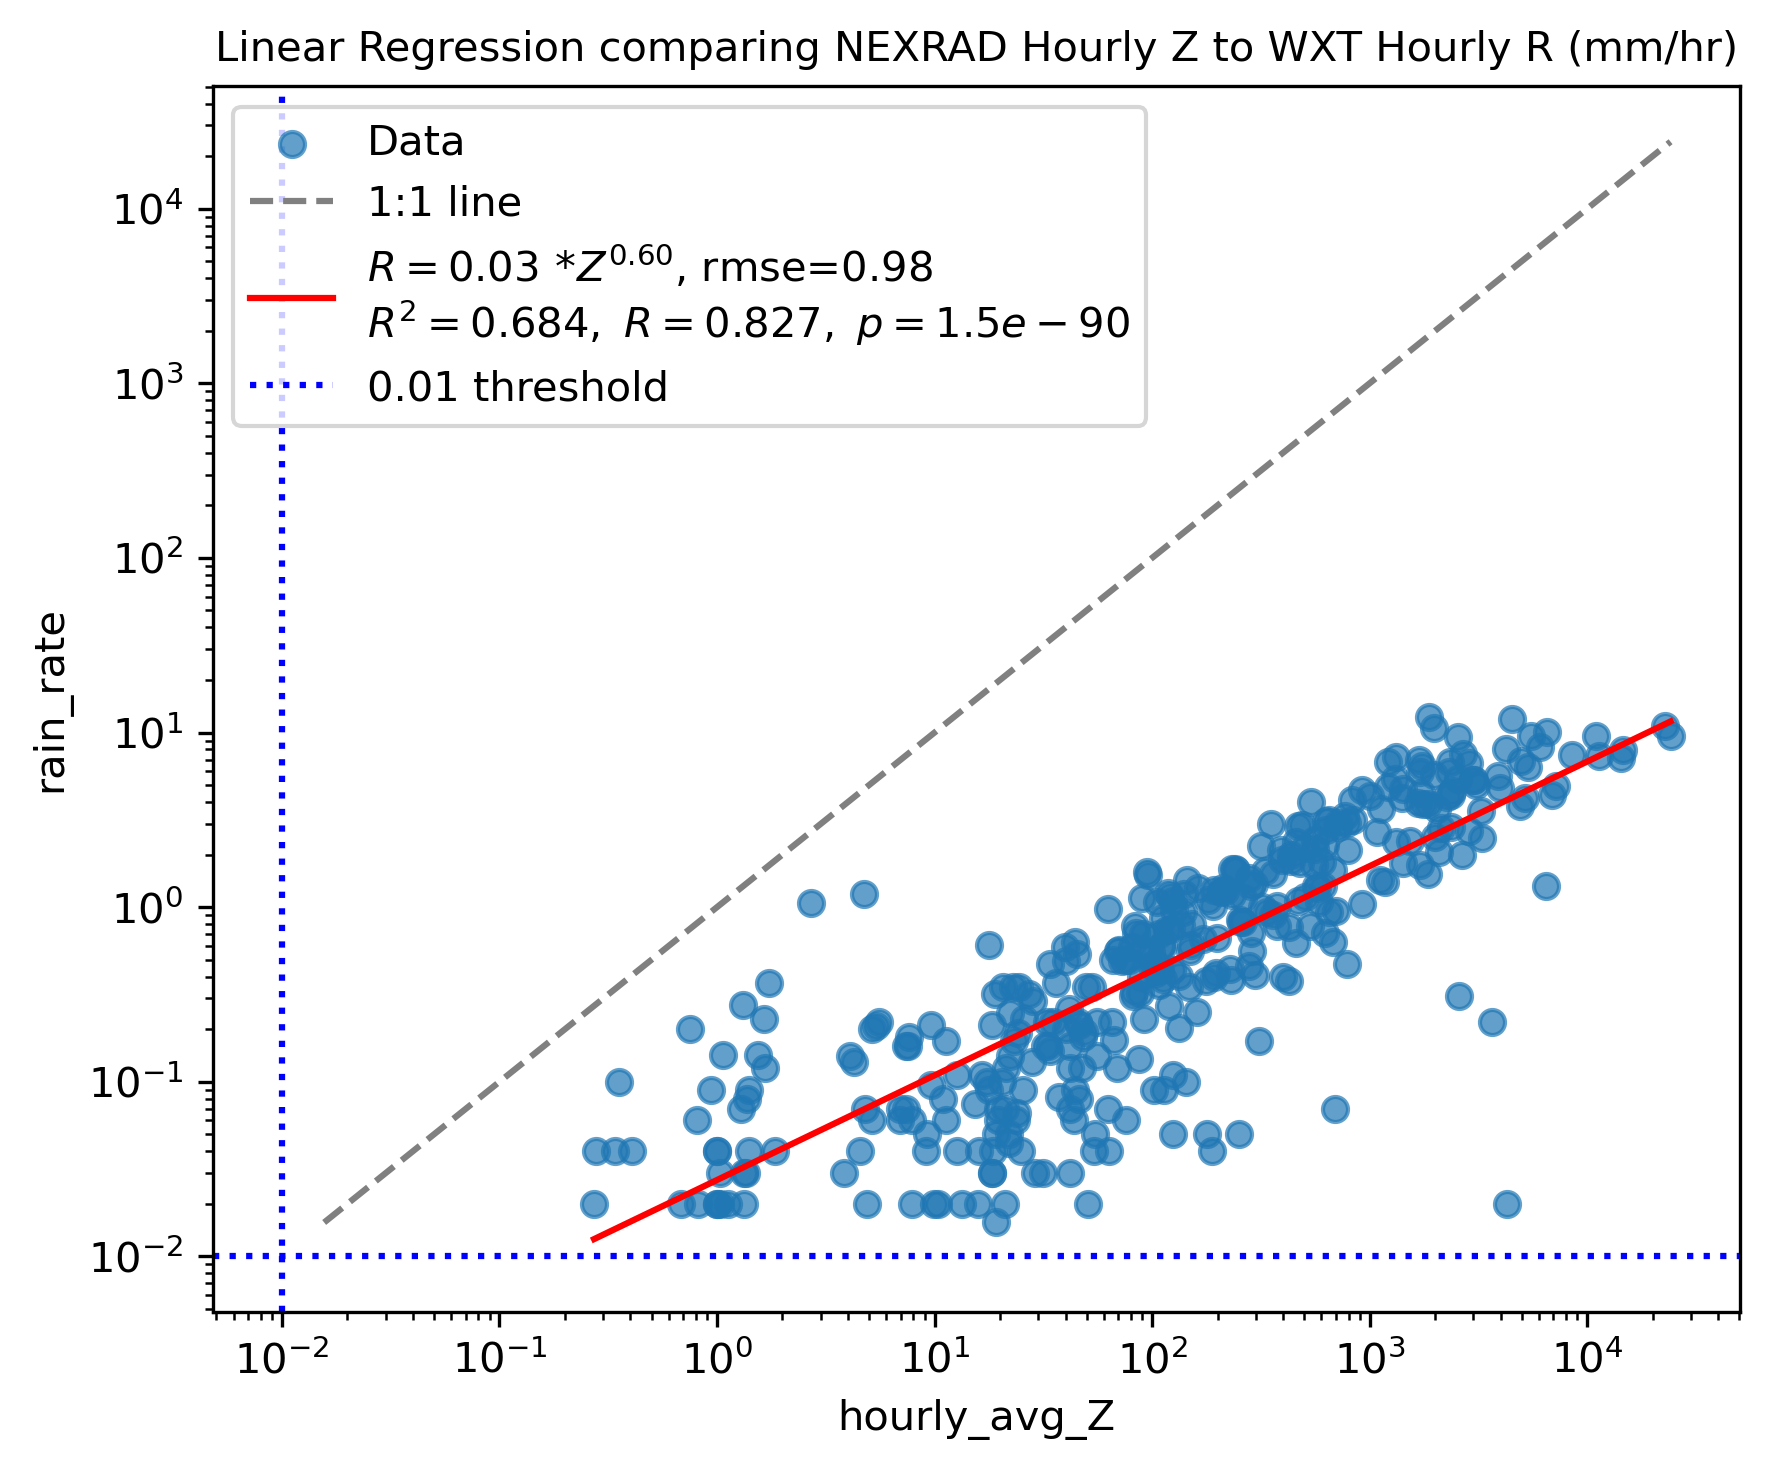

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from typing import Tuple
import seaborn as sns

plt.style.use("default")


def log_log_regression_plot(
    df: pd.DataFrame, x_col: str, y_col: str, min_val: float = 0.011, dpi: int = 150
) -> Tuple[float, float, float, float, float, float, float]:
    """
    Fit y = a * x^b by doing a linear regression i
    n log-space,
    plot the data, 1:1 line & fit on log–log axes,
    and return (a, b, R^2, r, RMSE_log, p-value, stderr).
    """
    # 1) grab arrays
    x = df[x_col].values
    y = df[y_col].values

    # 2) filter zeros/negatives
    mask = (x > min_val) & (y > min_val)
    x = x[mask]
    y = y[mask]
    print(len(x))
    print(len(y))

    # 3) logs
    ln_x = np.log(x)
    ln_y = np.log(y)

    # 4) linear regression in log-space: ln(y) = intcpt + slope * ln(x)
    slope, intercept, r_value, p_value, stderr = linregress(ln_x, ln_y)

    # back out a, b, R², RMSE
    b = slope
    a = np.exp(intercept)
    R2 = r_value**2
    ln_y_pred = intercept + slope * ln_x
    rmse_log = np.sqrt(np.mean((ln_y - ln_y_pred) ** 2))
    r = r_value

    # 5) prepare fit curve
    x_fit = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
    y_fit = a * x_fit**b

    plt.figure(figsize=(6, 5), dpi=dpi)

    # scatter
    plt.scatter(x, y, label="Data", alpha=0.7)

    # 1:1 line
    min_axis = max(min_val, min(x.min(), y.min()))
    max_axis = max(x.max(), y.max())
    plt.plot(
        [min_axis, max_axis],
        [min_axis, max_axis],
        ls="--",
        color="gray",
        label="1:1 line",
    )
    print(rmse_log)

    # regression fit
    plt.plot(
        x_fit,
        y_fit,
        color="red",
        label=(
            rf"$R={a:.2f}\,* \!Z^{{{b:.2f}}}$, rmse={rmse_log:.2f}" + "\n"
            rf"$R^2={R2:.3f},\ R={r:.3f},\ p={p_value:.1e}$"
        ),
    )
    plt.axhline(0.01, color="blue", linestyle=":", label="0.01 threshold")
    plt.axvline(0.01, color="blue", linestyle=":")
    # log axes, labels, etc.
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(
        f"Linear Regression comparing NEXRAD Hourly Z to WXT Hourly R (mm/hr)",
        fontsize=10,
    )
    plt.legend(fontsize=10, loc="upper left")
    # plt.grid(which="both", ls="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig("linreg.png", dpi=300, bbox_inches="tight")
    plt.show()

    return a, b, R2, r, rmse_log, p_value, stderr


a, b, R2, r, rmse, pval, stderr = log_log_regression_plot(
    df_masked,
    x_col="hourly_avg_Z",
    y_col="rain_rate",
    min_val=0.011,
    dpi=300,
)

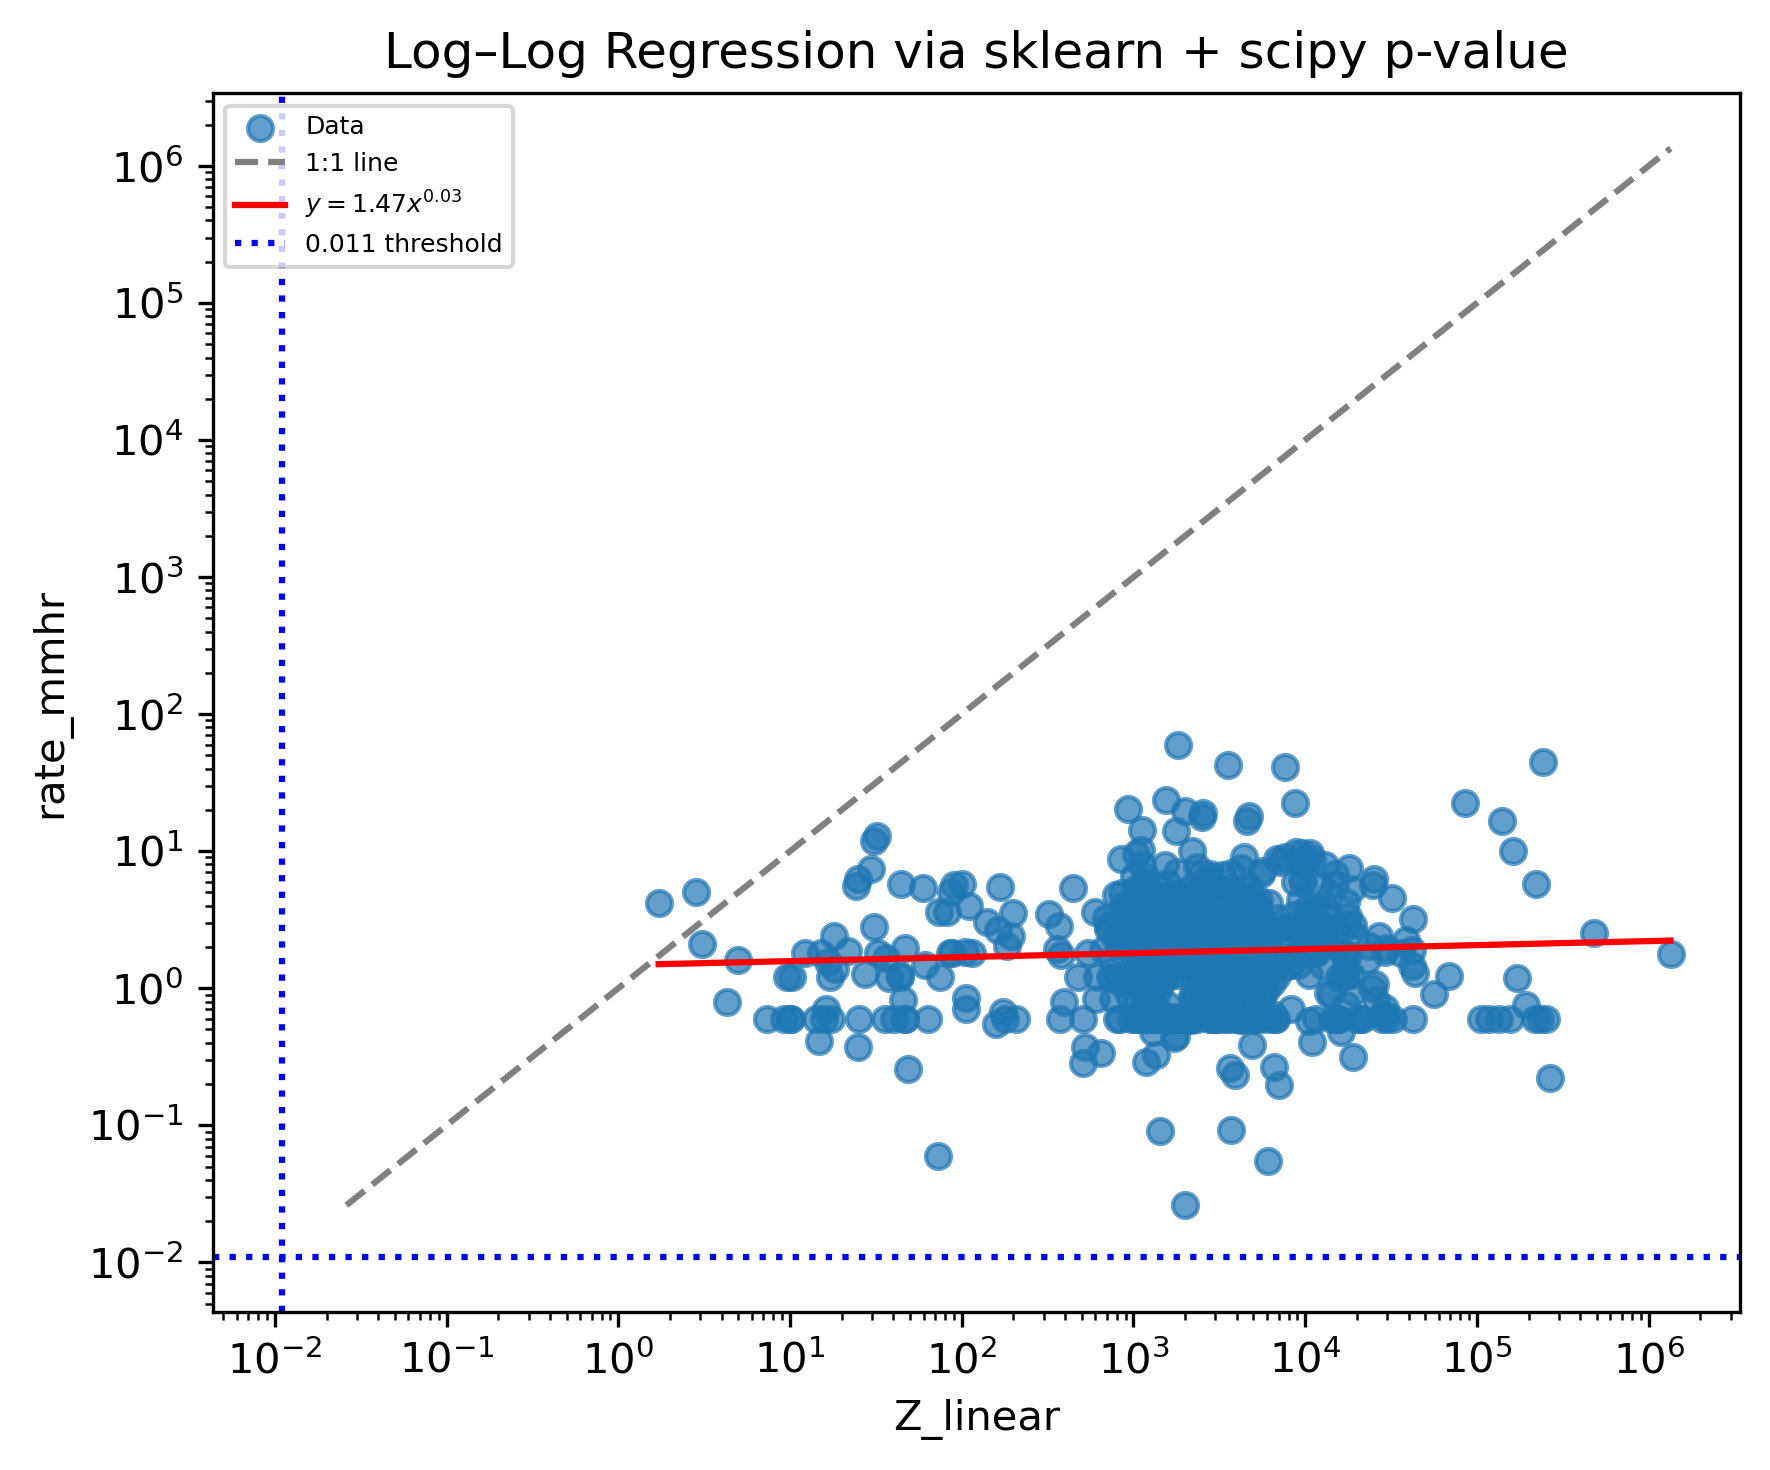

a=1.475, b=0.029, R²=0.003, p=1.5e-01


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from typing import Tuple


def log_log_regression_plot_sklearn(
    df, x_col: str, y_col: str, min_val: float = 0.011, dpi: int = 150
) -> Tuple[float, float, float, float, float, float, float]:
    """
    Fit y = a * x^b by regressing ln(x) → ln(y) with sklearn, plot data + line,
    and extract p-value & stderr from scipy.linregress.
    Returns: (a, b, R2, r, rmse_log, p_value, stderr)
    """
    # 1) threshold raw data
    x = df[x_col].values
    y = df[y_col].values
    mask = (x > min_val) & (y > min_val)
    x, y = x[mask], y[mask]

    # 2) log-transform
    ln_x = np.log(x).reshape(-1, 1)
    ln_y = np.log(y)

    # 3) fit with sklearn
    model = LinearRegression()
    model.fit(ln_x, ln_y)
    b = model.coef_[0]
    intercept = model.intercept_
    a = np.exp(intercept)

    # 4) sklearn metrics
    R2 = model.score(ln_x, ln_y)
    ln_y_pred = model.predict(ln_x)
    rmse_log = np.sqrt(np.mean((ln_y - ln_y_pred) ** 2))

    # 5) get p-value & stderr via scipy
    _, _, r_value, p_value, stderr = linregress(ln_x.flatten(), ln_y)
    r = r_value

    # 6) prepare smooth regression line via sklearn.predict
    ln_x_grid = np.linspace(ln_x.min(), ln_x.max(), 200).reshape(-1, 1)
    ln_y_grid = model.predict(ln_x_grid)
    x_grid = np.exp(ln_x_grid.flatten())
    y_grid = np.exp(ln_y_grid)

    # 7) plotting
    plt.figure(figsize=(6, 5), dpi=dpi)
    plt.scatter(x, y, label="Data", alpha=0.7)
    # 1:1 reference
    min_axis = max(min_val, min(x.min(), y.min()))
    max_axis = max(x.max(), y.max())
    plt.plot(
        [min_axis, max_axis],
        [min_axis, max_axis],
        ls="--",
        color="gray",
        label="1:1 line",
    )
    # sklearn regression line
    plt.plot(x_grid, y_grid, color="red", label=rf"$y={a:.2f}x^{{{b:.2f}}}$")
    # threshold lines
    plt.axhline(min_val, color="blue", ls=":", label=f"{min_val} threshold")
    plt.axvline(min_val, color="blue", ls=":")
    # log axes & labels
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title("Log–Log Regression via sklearn + scipy p-value")
    plt.legend(fontsize=6, loc="upper left")
    plt.tight_layout()
    plt.show()

    return a, b, R2, r, rmse_log, p_value, stderr


# assuming you’ve already defined log_log_regression_plot_sklearn(...)
# and computed df_masked via your mask_df:

a, b, R2, r, rmse_log, p_value, stderr = log_log_regression_plot_sklearn(
    df_masked, x_col="Z_linear", y_col="minute_mm", min_val=0.011, dpi=300
)

print(f"a={a:.3f}, b={b:.3f}, R²={R2:.3f}, p={p_value:.1e}")

In [88]:
df

,Unnamed: 0,time,minute_mm,rate_mmhr,rain_rate,Zh,Kdp,Ai,Z_linear
0,0,2025-04-15 00:00:00,0.0,0.0,0.0,-41.760728,2.572287e-10,1.039610e-11,0.000067
1,1,2025-04-15 00:01:00,0.0,0.0,0.0,-41.760728,2.572287e-10,1.039610e-11,0.000067
2,2,2025-04-15 00:02:00,0.0,0.0,0.0,-41.760728,2.572287e-10,1.039610e-11,0.000067
3,3,2025-04-15 00:03:00,0.0,0.0,0.0,-41.760728,2.572287e-10,1.039610e-11,0.000067
4,4,2025-04-15 00:04:00,0.0,0.0,0.0,-41.760728,2.572287e-10,1.039610e-11,0.000067
...,...,...,...,...,...,...,...,...,...
79435,89270,2025-06-15 23:50:00,0.0,0.0,0.0,-41.760728,2.626067e-10,1.067016e-11,0.000067
79436,89271,2025-06-15 23:51:00,0.0,0.0,0.0,-41.760728,2.626067e-10,1.067016e-11,0.000067
79437,89272,2025-06-15 23:52:00,0.0,0.0,0.0,-41.760728,2.626067e-10,1.067016e-11,0.000067
79438,89273,2025-06-15 23:53:00,0.0,0.0,0.0,-41.760728,2.626067e-10,1.067016e-11,0.000067


# For augmented vs clean data

177
177
1.026603218991016
153
153
0.9576473317436925


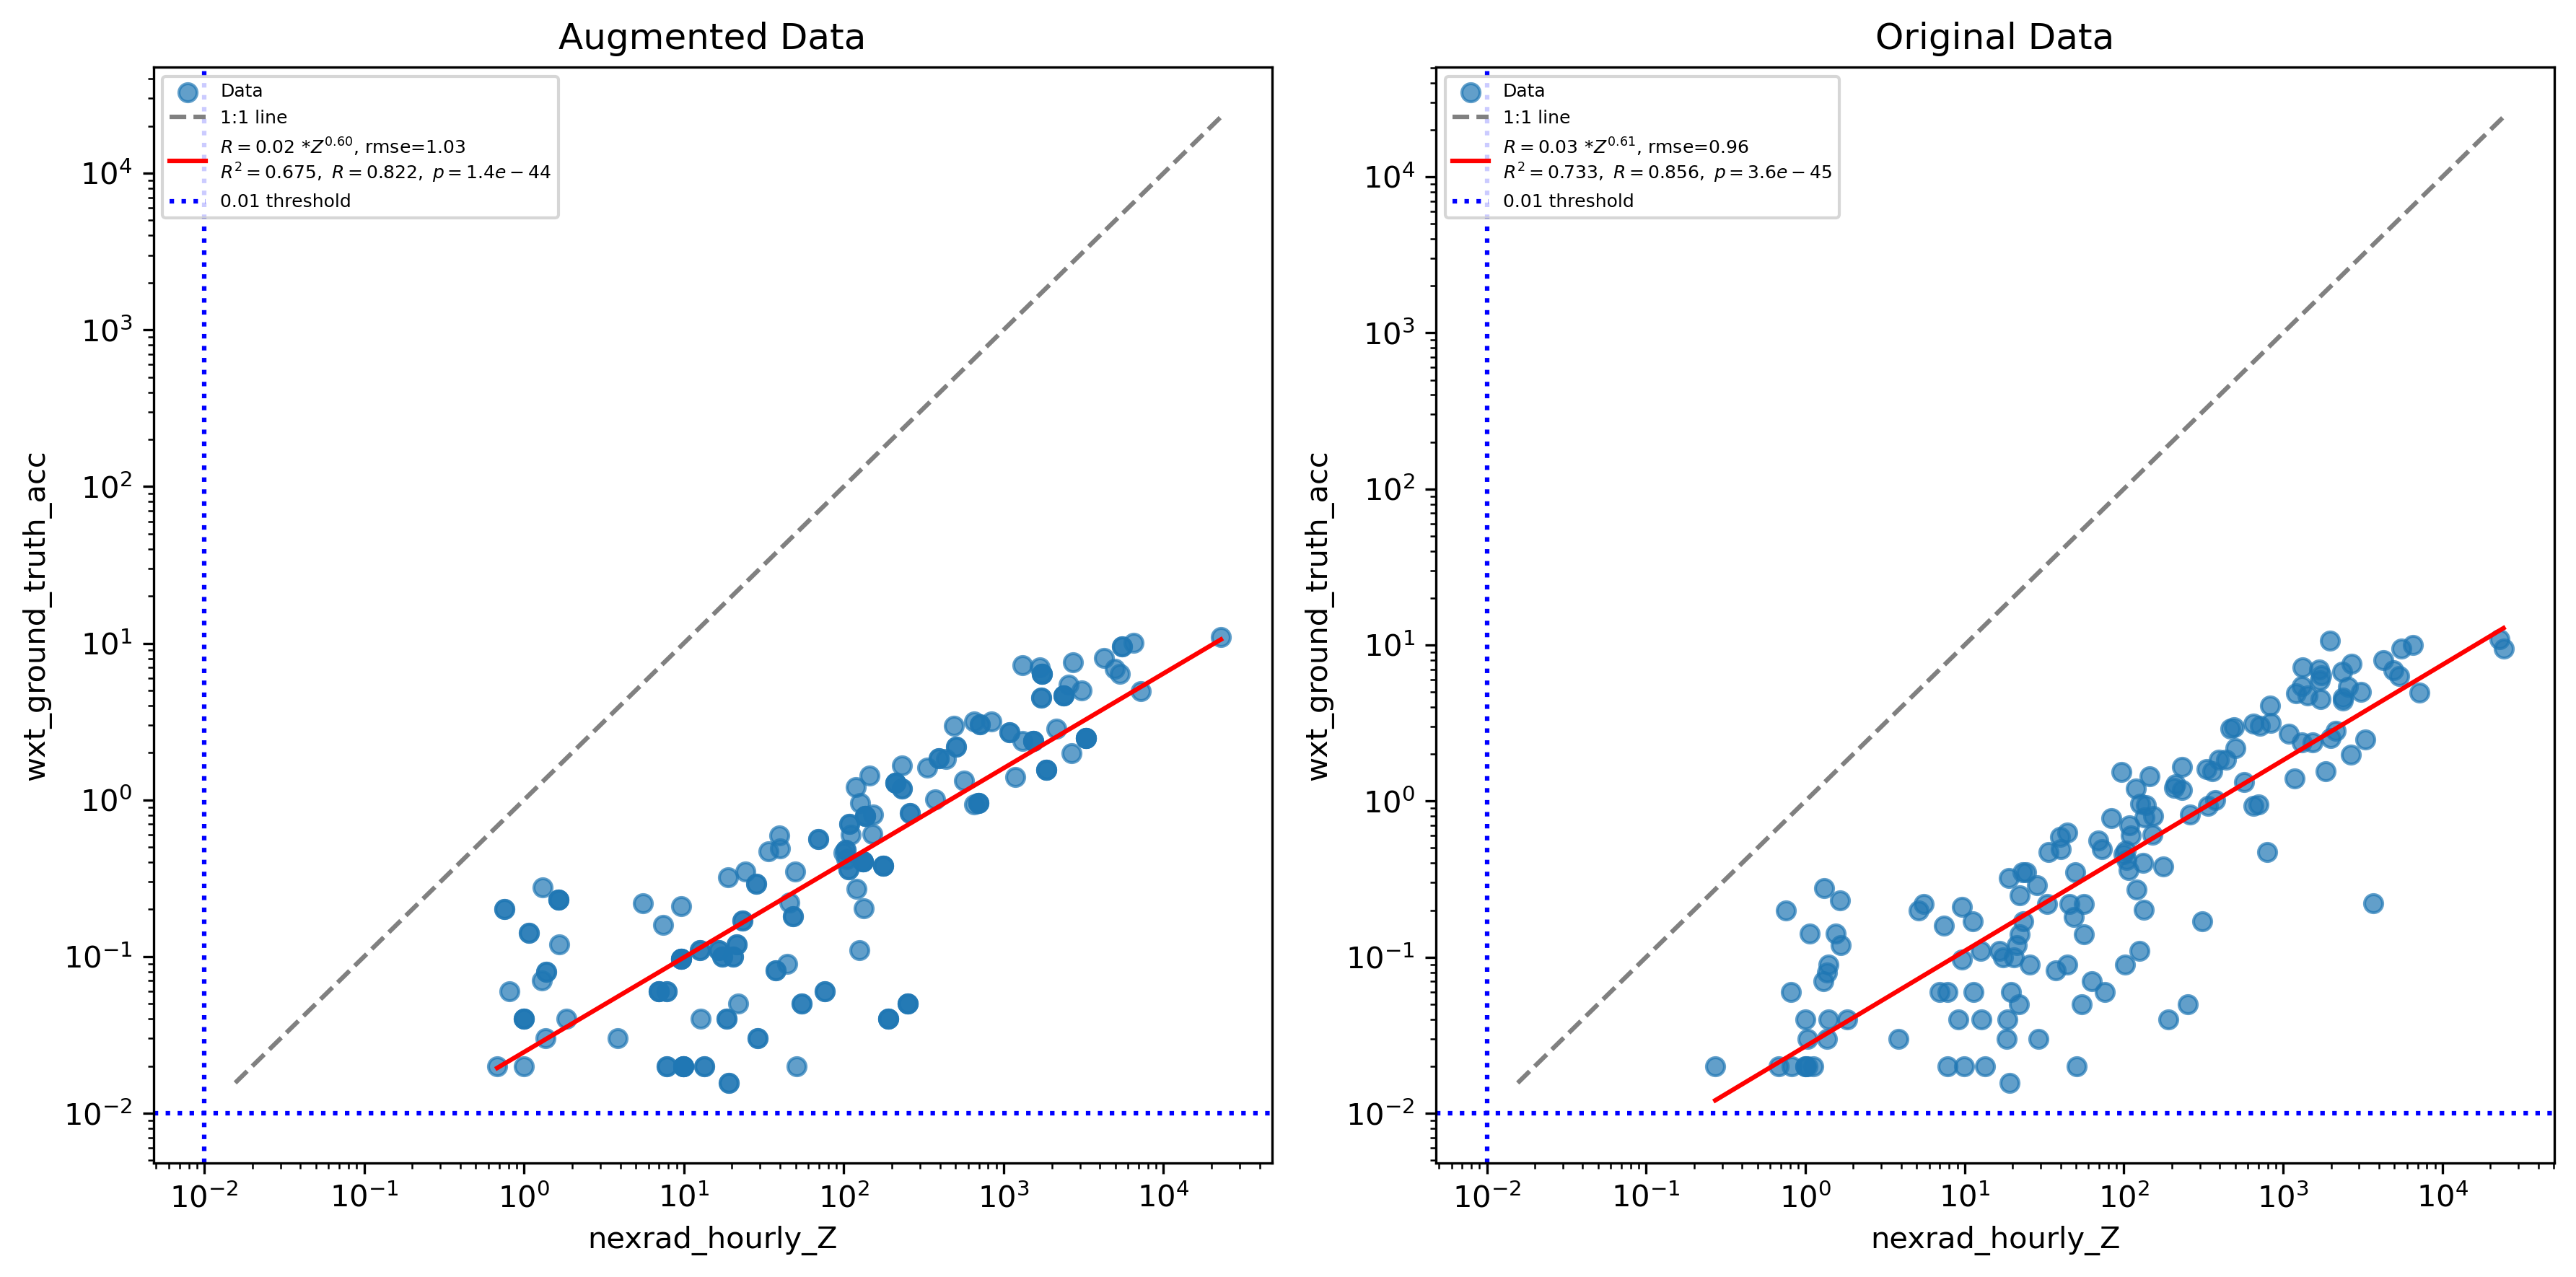

In [ ]:
import importlib
import matplotlib.pyplot as plt

# 1) Reload pyplot to clear any previous monkey-patches
importlib.reload(plt)

# 2) Create a 1×2 figure
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=300)

# 3) Monkey-patch plt.figure/plt.show so that your function draws into the current axes
_orig_fig = plt.figure
_orig_show = plt.show
plt.figure = lambda *args, **kwargs: fig
plt.show = lambda *args, **kwargs: None

# 4) Plot augmented data in the left subplot
plt.sca(axes[0])
log_log_regression_plot(
    df_aug,
    x_col="nexrad_hourly_Z",
    y_col="wxt_ground_truth_acc",
    min_val=0.011,
    dpi=300,
)
axes[0].set_title("Augmented Data")

# 5) Plot original data in the right subplot
plt.sca(axes[1])
log_log_regression_plot(
    df, x_col="nexrad_hourly_Z", y_col="wxt_ground_truth_acc", min_val=0.011, dpi=300
)
axes[1].set_title("Original Data")

# 6) Restore matplotlib’s normal behavior and finalize
plt.figure = _orig_fig
plt.show = _orig_show

plt.tight_layout()
plt.show()

Intercept: 0.20761783106654674
Coefficients: {'hourly_avg_kdp': np.float64(-0.11592244489172973), 'hourly_avg_Z': np.float64(0.00016960051847594797)}


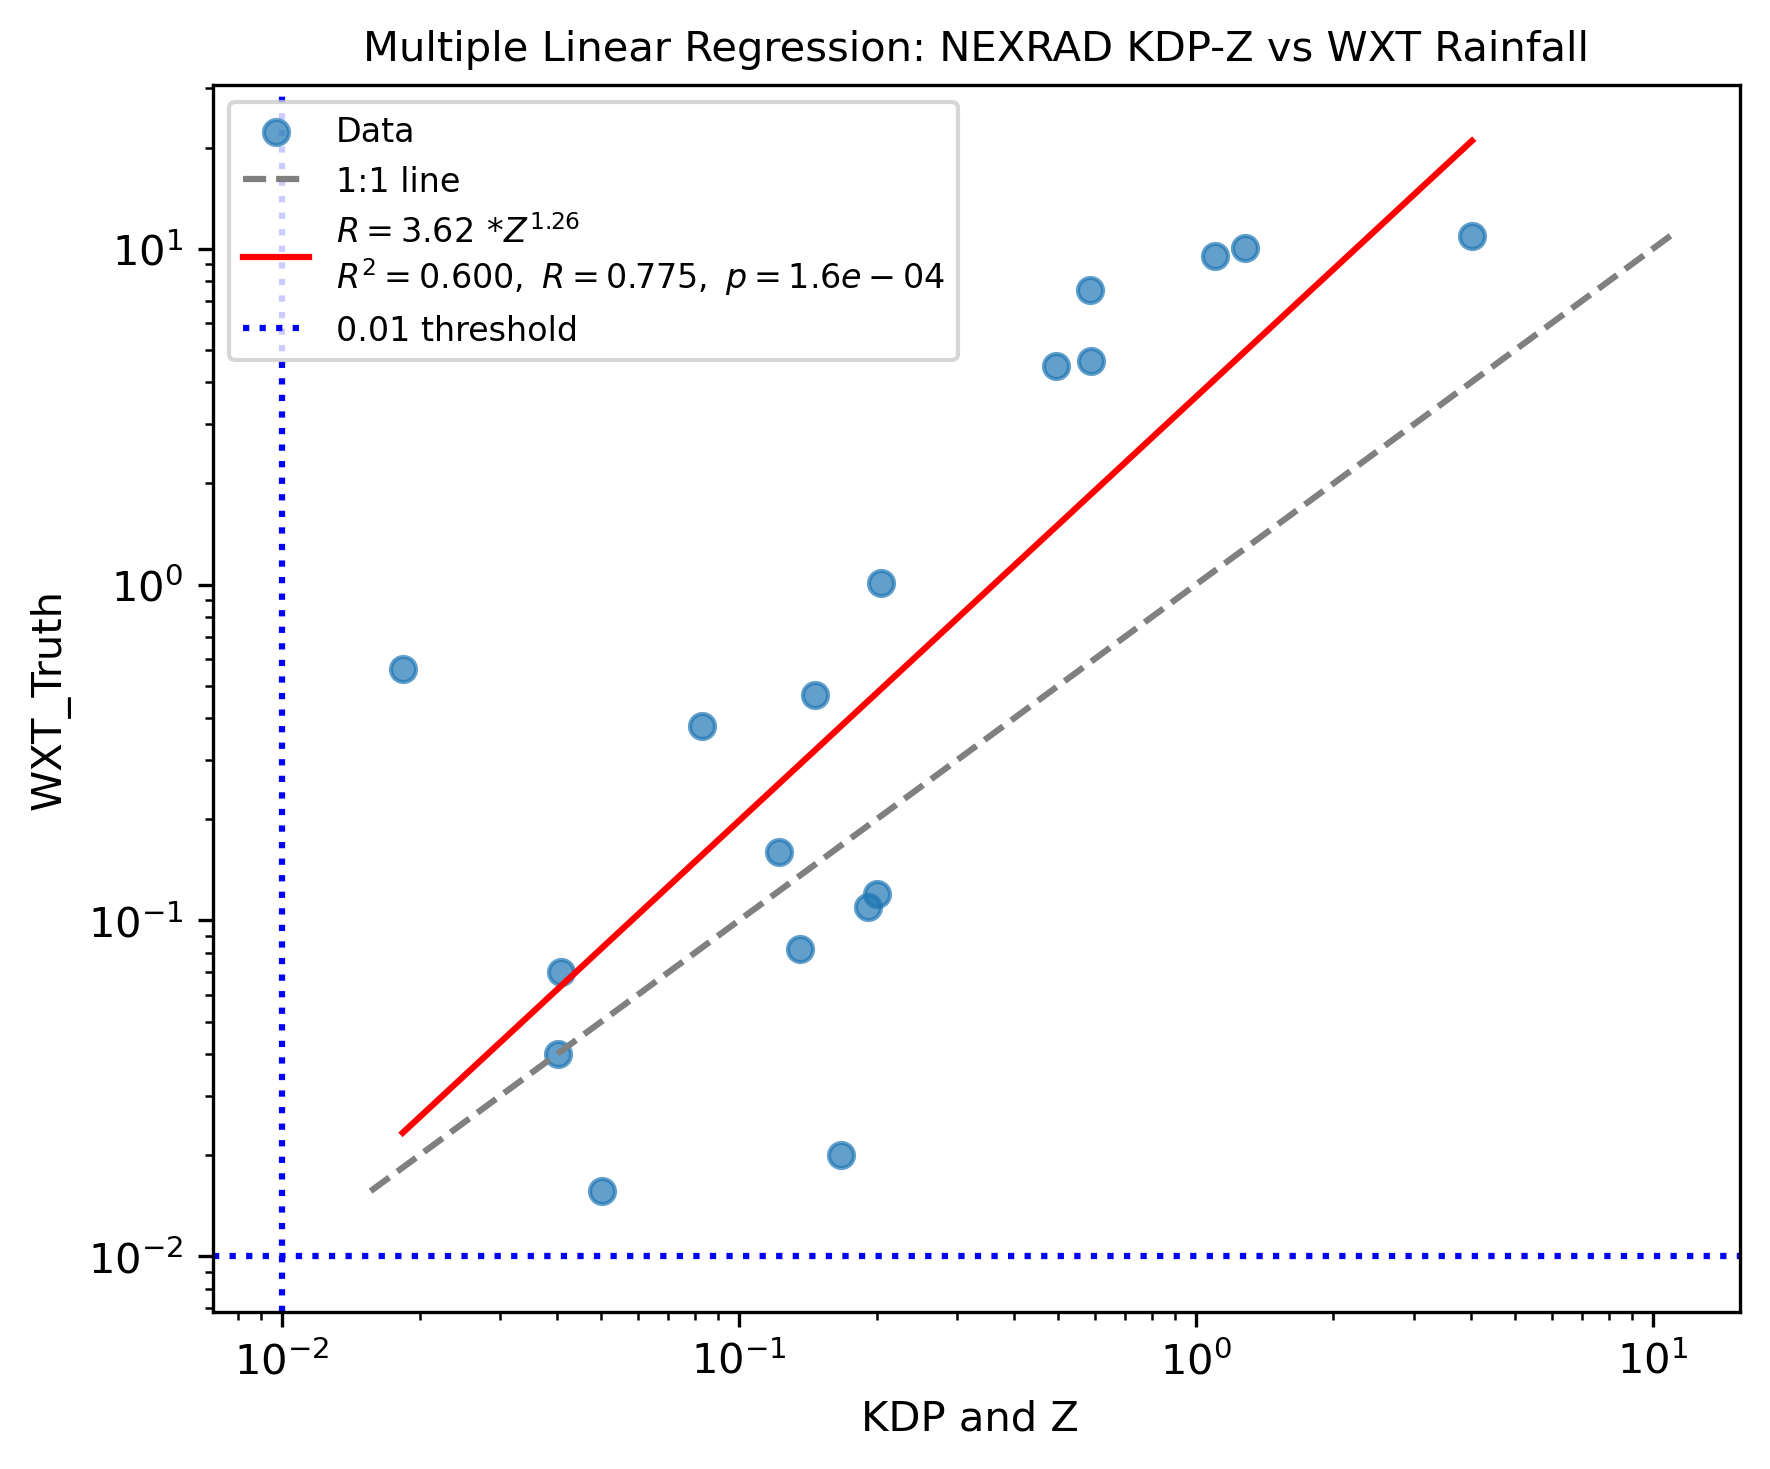

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy import linalg
from typing import Tuple


def log_log_regression_plot(
    df: pd.DataFrame, x_col: str, y_col: str, min_val: float = 0.011, dpi: int = 150
) -> Tuple[float, float, float, float, float, float, float]:
    """
    (unchanged) Fit y = a * x^b by doing a linear regression in log-space,
    plot the data, 1:1 line & fit on log–log axes,
    and return (a, b, R^2, r, RMSE_log, p-value, stderr).
    """
    x = df[x_col].values
    y = df[y_col].values
    mask = (x > min_val) & (y > min_val)
    x = x[mask]
    y = y[mask]
    ln_x = np.log(x)
    ln_y = np.log(y)

    slope, intercept, r_value, p_value, stderr = linregress(ln_x, ln_y)
    b = slope
    a = np.exp(intercept)
    R2 = r_value**2
    ln_y_pred = intercept + slope * ln_x
    rmse_log = np.sqrt(np.mean((ln_y - ln_y_pred) ** 2))
    r = r_value

    x_fit = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
    y_fit = a * x_fit**b

    plt.figure(figsize=(6, 5), dpi=dpi)
    plt.scatter(x, y, label="Data", alpha=0.7)
    min_axis = max(min_val, min(x.min(), y.min()))
    max_axis = max(x.max(), y.max())
    plt.plot(
        [min_axis, max_axis],
        [min_axis, max_axis],
        ls="--",
        color="gray",
        label="1:1 line",
    )
    plt.plot(
        x_fit,
        y_fit,
        color="red",
        label=(
            rf"$R={a:.2f}\,* \!Z^{{{b:.2f}}}$" + "\n"
            rf"$R^2={R2:.3f},\ R={r:.3f},\ p={p_value:.1e}$"
        ),
    )
    plt.axhline(0.01, color="blue", linestyle=":", label="0.01 threshold")
    plt.axvline(0.01, color="blue", linestyle=":")
    plt.xscale("log")
    plt.yscale("log")
    plt.ylabel("WXT_Truth")
    plt.xlabel("KDP and Z ")
    plt.title("Multiple Linear Regression: NEXRAD KDP-Z vs WXT Rainfall", fontsize=10)
    plt.legend(fontsize=8, loc="upper left")
    plt.tight_layout()
    plt.show()

    return a, b, R2, r, rmse_log, p_value, stderr


# ——— MULTIPLE LINEAR REGRESSION VIA scipy.linalg.lstsq ————————

# 1) choose your predictors and target in df
predictors = ["hourly_avg_kdp", "hourly_avg_Z"]
target = "hourly_rainfall_>=5C"

# 2) build arrays
X = df_merged[predictors].to_numpy()  # shape (n_samples, n_features)
y = df_merged[target].to_numpy()  # shape (n_samples,)

# 3) construct design matrix with intercept
ones = np.ones((X.shape[0], 1))
X_design = np.hstack([ones, X])  # shape (n_samples, n_features+1)

# 4) solve via least squares
beta, *_ = linalg.lstsq(X_design, y)  # beta[0]=intercept, beta[1:]=coefs
intercept = beta[0]
coefs = beta[1:]

print("Intercept:", intercept)
print("Coefficients:", dict(zip(predictors, coefs)))

# 5) predict on the same data
y_pred = X_design.dot(beta)

# 6) prepare DataFrame of true vs predicted
df_pred = pd.DataFrame({target: y, "pred": y_pred})

# 7) call your unchanged log–log plot
a, b, R2, r, rmse, pval, stderr = log_log_regression_plot(
    df_pred, x_col="pred", y_col=target, min_val=0.011, dpi=300
)

# Scikit-Learn Linear regression

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load CSV (you already have this)
# df = pd.read_csv("your_data.csv")

# Convert dBZ to linear Z:
# Z_lin = 10 ** (df["nexrad_avg_ref"] / 10)

# Rain rate:
R = df["wxt_ground_truth_acc"]
Z_lin = df["nexrad_avg_pcp"]
print(R.min())

# Filter out invalid values:
mask = (Z_lin > 1e-4) & (R > 1e-4)
Z_lin = Z_lin[mask]
R = R[mask]
print(R.min())

# Take logs:
ln_Z = np.log(Z_lin.values).reshape(-1, 1)  # sklearn expects 2D array for X
ln_R = np.log(R.values).reshape(-1, 1)

# Fit using scikit-learn LinearRegression
reg = LinearRegression()
reg.fit(ln_Z, ln_R)

# Get slope and intercept
b = reg.coef_[0, 0]
ln_a = reg.intercept_[0]
a = np.exp(ln_a)

# Predict ln R:
ln_R_pred = reg.predict(ln_Z)

# Compute R^2:
r_squared = reg.score(ln_Z, ln_R)
r = np.sqrt(r_squared)
# Compute RMSE (optional)
rmse = np.sqrt(mean_squared_error(ln_R, ln_R_pred))
sig_level = 1 - reg.score(ln_Z, ln_R)

# Print results:
print(f"Z-R relationship: R = {a:.4f} * Z^{b:.4f}")
print(f"R^2 = {r_squared:.4f}")
print(f"RMSE (ln space) = {rmse:.4f}")

# Plot:
Z_fit = np.linspace(min(Z_lin), max(Z_lin), 100)
ln_Z_fit = np.log(Z_fit).reshape(-1, 1)
ln_R_fit = reg.predict(ln_Z_fit)
R_fit = np.exp(ln_R_fit)

plt.figure(figsize=(12, 8), dpi=300)
plt.scatter(Z_lin, R, label="Data", alpha=0.7)
plt.plot(Z_fit, R_fit, color="red", label=f"Fit: R = {a:.2f} * Z^{b:.2f}")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Z (linear units)")
plt.ylabel("Rain rate (R)")
plt.legend()
plt.title(
    f"2nd Sweep Linear Regression with ln(hrly_rainfall) fit to ln(Z)\n$R^2$ = {r_squared:.3f}, R = {r:.3f}, RMSE = {rmse:.4f} "
)
plt.show()

KeyError: 'nexrad_avg_pcp'

In [ ]:
import xarray as xr

xr.open_dataset("nexrad_nc/nxrd_data_linreg_2024_pt2.nc")

<xarray.Dataset> Size: 730kB
Dimensions:                   (time: 30418)
Coordinates:
  * time                      (time) datetime64[ns] 243kB 2024-05-04T00:03:50...
Data variables:
    reflectivity_lowest_gate  (time) float64 243kB ...
    height_lowest_gate        (time) float64 243kB ...
Attributes:
    history:  Created 2025-06-11T15:39:06.615357